In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [8]:
class temperatureState(TypedDict):
    celsius : float
    fahrenheit : float
    whether : str

In [9]:
def temp_convertion(state:temperatureState) -> temperatureState:
    celsius = state['celsius']
    fahrenheit = celsius*(9/5) + 32
    state['fahrenheit'] = fahrenheit
    return state

In [18]:
def label_weather(state:temperatureState) -> temperatureState:
    fahrenheit = state['fahrenheit']
    if fahrenheit < 50:
        state["weather"] = "Cold"
    elif 50 <= fahrenheit < 77:
        state["weather"] = "Mild"
    elif 77 <= fahrenheit < 95:
        state["weather"] = "Hot"
    else:
        state["weather"] = "Extreme Heat"
        
    return state

In [19]:
graph = StateGraph(temperatureState)

graph.add_node("temperature_convertion",temp_convertion)
graph.add_node("label_weather",label_weather)

graph.add_edge(START, "temperature_convertion")
graph.add_edge("temperature_convertion","label_weather")
graph.add_edge("label_weather",END)

workflow = graph.compile()

In [20]:
initial_state = {"celsius" : 29.5}
final_state = workflow.invoke(initial_state)
print(final_state)

{'celsius': 29.5, 'fahrenheit': 85.1}


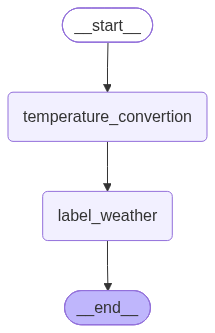

In [22]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())